# Standalone EMStage for Censored Density Estimation

This notebook demonstrates how to use the `EMStage` class independently to refine any initial density estimate for right-censored data.

## Key Concept: Separation of Concerns

The refactored architecture separates:
1. **Initial Estimator**: Any estimator that provides a working density model
2. **EM Stage**: Iteratively refines the estimate using multiple imputation

This allows you to:
- Use any initial estimator (IPCW, oracle, etc.)
- Run EM refinement independently
- Experiment with different initialization strategies

## Workflow

1. Fit an initial density estimator (e.g., `WeightedCVXPYEstimator` with IPCW)
2. Create an `EMStage` instance with EM configuration
3. Call `em_stage.run(initial_estimator, data, S_c_predict)` to refine
4. Use the result's `final_estimator` for predictions


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# HALDensity modules
from haldensity.censoring import (
    KaplanMeier,
    compute_ipcw_weights,
    WeightedCVXPYEstimator,
    EMStage,
    EMStageResult,
    EMIPCWEstimator,
    incomplete_loglik,
    kl_divergence,
)

print("Imports successful")


Imports successful


/Users/houyilong/Documents/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Generate Right-Censored Data

We simulate data from a truncated normal distribution with uniform censoring.


In [2]:
# Simulation parameters
np.random.seed(42)
rng = np.random.default_rng(42)

n_samples = 500
mean, std = 0.5, 0.15
lower, upper = 0.0, 1.0

# Generate truncated normal event times
a, b = (lower - mean) / std, (upper - mean) / std
X_true = truncnorm.rvs(a, b, loc=mean, scale=std, size=n_samples, random_state=rng)

# Generate uniform censoring times
C = rng.uniform(lower, upper, size=n_samples)

# Observed data
T = np.minimum(X_true, C)
Delta = (X_true <= C).astype(int)

# Store in DataFrame
data = pd.DataFrame({"T": T, "Delta": Delta})

# True density function for evaluation
true_pdf = lambda x: truncnorm.pdf(x, a, b, loc=mean, scale=std)

print(f"Sample size: {n_samples}")
print(f"Censoring rate: {(1 - Delta.mean()):.1%}")
print(f"Observed events: {Delta.sum()}")


Sample size: 500
Censoring rate: 50.6%
Observed events: 247


## 2. Fit Kaplan-Meier for Censoring Survival

The EM algorithm needs an estimate of the censoring survival function S_c(t) = P(C > t).


In [3]:
# Fit Kaplan-Meier for censoring survival
km = KaplanMeier().fit(data, time_col="T", delta_col="Delta")

# Create a wrapper function for S_c prediction
def S_c_predict(t):
    """Predict censoring survival probability."""
    return np.atleast_1d(km.predict(t))

print(f"S_c(0.0) = {km.predict(0.0):.3f}")
print(f"S_c(0.5) = {km.predict(0.5):.3f}")
print(f"S_c(1.0) = {km.predict(1.0):.3f}")


S_c(0.0) = 1.000
S_c(0.5) = 0.476
S_c(1.0) = 0.146


## 3. Fit Initial IPCW Estimator

We first fit a weighted HAL estimator on the uncensored observations using IPCW weights.
This serves as our initial estimate that will be refined by the EM stage.


In [4]:
# Compute IPCW weights
T_vals = np.asarray(data["T"].values, dtype=float)
Delta_vals = np.asarray(data["Delta"].values, dtype=int)

ipcw_weights = compute_ipcw_weights(
    T=T_vals,
    Delta=Delta_vals,
    S_c_predict=S_c_predict,
)

# Create data for fitting (uncensored observations only)
uncensored_mask = Delta_vals == 1
ipcw_data = pd.DataFrame({"W1": T_vals[uncensored_mask]})

print(f"Uncensored observations: {uncensored_mask.sum()}")
print(f"IPCW weights: min={ipcw_weights[uncensored_mask].min():.3f}, "
      f"max={ipcw_weights[uncensored_mask].max():.3f}")


Uncensored observations: 247
IPCW weights: min=1.149, max=6.855


In [5]:
# Fit the initial IPCW estimator
initial_estimator = WeightedCVXPYEstimator(
    norm_constraint=100.0,
    n_grid_points=200,
    basis_order=1,  # Linear splines
    solver="ECOS",
)
initial_estimator.fit(ipcw_data, sample_weights=ipcw_weights[uncensored_mask])

# Evaluate initial estimate
eval_grid = np.linspace(0.01, 0.99, 300)
initial_density = initial_estimator.get_density_at_points(eval_grid)
initial_ll = incomplete_loglik(initial_estimator, data, time_col="T", delta_col="Delta")
initial_kl = kl_divergence(true_pdf, eval_grid, initial_density)

print(f"\nInitial IPCW Estimator:")
print(f"  Incomplete-data log-likelihood: {initial_ll:.4f}")
print(f"  KL divergence from true: {initial_kl:.6f}")
print(f"  Selected knots: {len(initial_estimator.grid_points_hal_selected)}")



Initial IPCW Estimator:
  Incomplete-data log-likelihood: 65.9182
  KL divergence from true: 0.019419
  Selected knots: 61


## 4. Run EMStage Standalone

Now we use `EMStage` to refine our initial estimate. The key insight is that `EMStage`
works with any estimator that provides:
- `theta_hat`: Coefficient vector
- `_grid_points_hal`: Basis knot locations
- `basis_order`: Polynomial order
- `get_density_at_points()`: Density evaluation method


In [6]:
# Create EMStage with configuration
em_stage = EMStage(
    m_imputations=25,         # Number of imputations per censored obs
    max_em_iter=15,           # Maximum EM iterations
    em_tol=1e-3,              # Convergence tolerance
    norm_constraint=100.0,    # L1 norm constraint for M-step
    n_grid_points=200,
    m_step_solver="ECOS",
    verbose=True,             # Print progress
    rng_seed=42,
)

print("EMStage configured. Running EM algorithm...\n")


EMStage configured. Running EM algorithm...



In [7]:
# Run EM refinement
result = em_stage.run(
    initial_estimator=initial_estimator,
    data=data,
    S_c_predict=S_c_predict,
)

print(f"\n{'='*50}")
print(f"EMStage completed!")
print(f"  Iterations: {result.em_iterations}")
print(f"  Converged: {result.em_converged}")
print(f"  Theta path length: {len(result.theta_path)}")


EMStage: Initial incomplete-data log-likelihood: 65.9182
[DEBUG][E-step-1] pooled samples=6572, weight_sum=500.0000, weight_range=(4.0000e-02, 1.0000e+00), value_range=(0.0891, 0.9950), unc_min=0.1219, cens_min=0.0891
[DEBUG][M-step-1] theta stats: shape=(251,), min=-22.7834, max=10.0229, mean=-0.0453, l1=99.9799, non_finite=0, knots=249, selected_knots=118
[DEBUG][M-step-1] density stats: min=5.7404e-03, max=2.8362e+00, integral=0.999852
EMStage Iter 1: LL=66.0715, Δ=0.153317, E-step=0.006s, M-step=0.252s
[DEBUG][E-step-2] pooled samples=6572, weight_sum=500.0000, weight_range=(4.0000e-02, 1.0000e+00), value_range=(0.1211, 1.0000), unc_min=0.1219, cens_min=0.1211
[DEBUG][M-step-2] theta stats: shape=(251,), min=-21.5759, max=10.8693, mean=-0.0453, l1=99.9844, non_finite=0, knots=249, selected_knots=106
[DEBUG][M-step-2] density stats: min=4.2215e-03, max=2.9416e+00, integral=0.999854
EMStage Iter 2: LL=66.0636, Δ=0.007979, E-step=0.003s, M-step=0.163s
[DEBUG][E-step-3] pooled samples=

In [8]:
# Evaluate final estimate
final_estimator = result.final_estimator
final_density = final_estimator.get_density_at_points(eval_grid)
final_ll = incomplete_loglik(final_estimator, data, time_col="T", delta_col="Delta")
final_kl = kl_divergence(true_pdf, eval_grid, final_density)

print(f"\nFinal EM-Refined Estimator:")
print(f"  Incomplete-data log-likelihood: {final_ll:.4f}")
print(f"  KL divergence from true: {final_kl:.6f}")
print(f"  Selected knots: {len(final_estimator.grid_points_hal_selected) if final_estimator.grid_points_hal_selected is not None else 0}")

print(f"\nImprovement over IPCW:")
print(f"  LL change: {final_ll - initial_ll:+.4f}")
print(f"  KL change: {final_kl - initial_kl:+.6f} (negative is better)")



Final EM-Refined Estimator:
  Incomplete-data log-likelihood: 66.1227
  KL divergence from true: 0.019657
  Selected knots: 113

Improvement over IPCW:
  LL change: +0.2045
  KL change: +0.000239 (negative is better)


## 5. Visualize Results


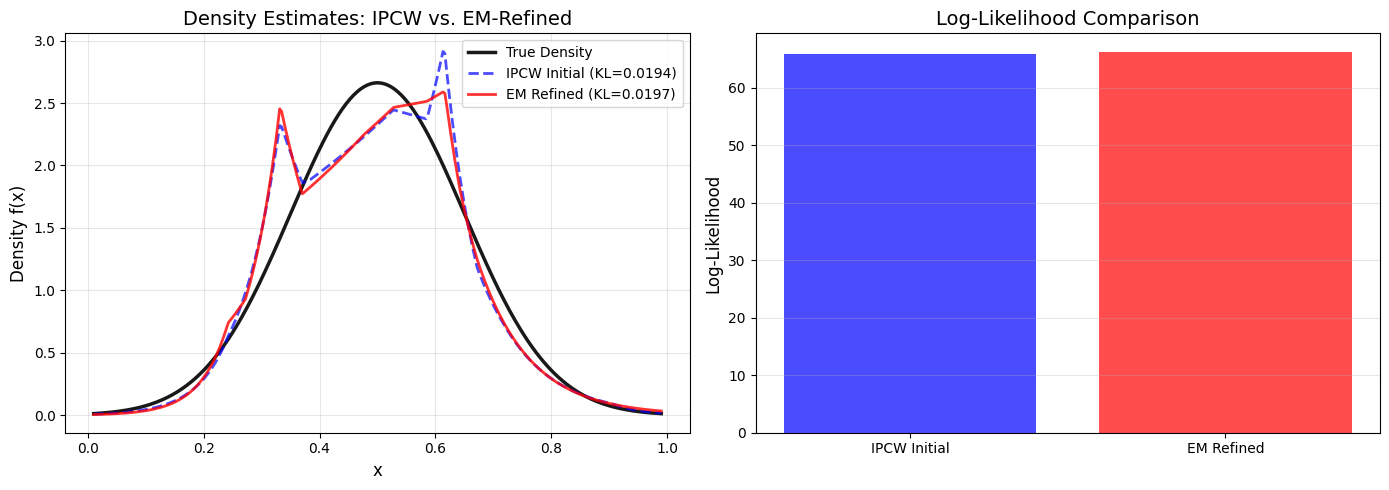

In [9]:
# Plot density comparison
true_density = true_pdf(eval_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Density estimates
ax1 = axes[0]
ax1.plot(eval_grid, true_density, 'k-', linewidth=2.5, label='True Density', alpha=0.9)
ax1.plot(eval_grid, initial_density, 'b--', linewidth=2, 
         label=f'IPCW Initial (KL={initial_kl:.4f})', alpha=0.7)
ax1.plot(eval_grid, final_density, 'r-', linewidth=2, 
         label=f'EM Refined (KL={final_kl:.4f})', alpha=0.8)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('Density f(x)', fontsize=12)
ax1.set_title('Density Estimates: IPCW vs. EM-Refined', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Log-likelihood comparison
ax2 = axes[1]
ax2.bar(['IPCW Initial', 'EM Refined'], [initial_ll, final_ll], color=['blue', 'red'], alpha=0.7)
ax2.set_ylabel('Log-Likelihood', fontsize=12)
ax2.set_title('Log-Likelihood Comparison', fontsize=14)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 6. Access the Augmented Data

The `EMStageResult` also provides access to the final augmented (imputed) dataset from the E-step.


In [10]:
# Inspect the augmented data from the final E-step
augmented = result.final_augmented_data

if augmented is not None:
    print(f"Augmented data shape: {augmented.shape}")
    print(f"\nWeight distribution:")
    print(f"  Uncensored (weight=1.0): {(augmented['weight'] == 1.0).sum()}")
    print(f"  Imputed (weight<1.0): {(augmented['weight'] < 1.0).sum()}")
    print(f"\nValue statistics:")
    print(augmented.describe())


Augmented data shape: (6572, 2)

Weight distribution:
  Uncensored (weight=1.0): 247
  Imputed (weight<1.0): 6325

Value statistics:
                W1       weight
count  6572.000000  6572.000000
mean      0.534176     0.076080
std       0.146299     0.182594
min       0.030030     0.040000
25%       0.430430     0.040000
50%       0.540541     0.040000
75%       0.626627     0.040000
max       0.992993     1.000000


## 7. Comparison with EMIPCWEstimator

For convenience, you can also use `EMIPCWEstimator` which combines IPCW initialization
and EM refinement in a single class. Both approaches should give similar results.


In [11]:
# EMIPCWEstimator combines IPCW + EM in one call
combined_estimator = EMIPCWEstimator(
    norm_constraint=100.0,
    m_imputations=25,
    max_em_iter=15,
    em_tol=1e-3,
    basis_order=1,
    init_solver="ECOS",
    m_step_solver="ECOS",
    rng_seed=42,
    verbose=False,
)
combined_estimator.fit(data)

combined_density = combined_estimator.get_density_at_points(eval_grid)
combined_ll = incomplete_loglik(combined_estimator, data, time_col="T", delta_col="Delta")
combined_kl = kl_divergence(true_pdf, eval_grid, combined_density)

print(f"EMIPCWEstimator Results:")
print(f"  EM iterations: {combined_estimator.em_iterations_}")
print(f"  EM converged: {combined_estimator.em_converged_}")
print(f"  Log-likelihood: {combined_ll:.4f}")
print(f"  KL divergence: {combined_kl:.6f}")

print(f"\nComparison (manual EMStage vs. EMIPCWEstimator):")
print(f"  LL difference: {abs(final_ll - combined_ll):.6f}")
print(f"  KL difference: {abs(final_kl - combined_kl):.6f}")


EMIPCWEstimator Results:
  EM iterations: 15
  EM converged: False
  Log-likelihood: 66.1241
  KL divergence: 0.019654

Comparison (manual EMStage vs. EMIPCWEstimator):
  LL difference: 0.001404
  KL difference: 0.000003


## Summary

The `EMStage` class provides a flexible way to refine density estimates:

1. **Separation**: Initial estimation is decoupled from EM refinement
2. **Flexibility**: Works with any estimator satisfying the protocol interface
3. **Transparency**: Access to theta path and augmented data
4. **Convenience**: Use `EMIPCWEstimator` for the common IPCW + EM workflow

### When to use which:

- **`EMIPCWEstimator`**: Quick, all-in-one solution for IPCW + EM
- **`EMStage` + custom initial**: When you want control over initialization or want to experiment with different initial estimators
